# Test 

Run using `mesmer_pypi` conda environment

In [2]:
import numpy as np 
import os 
import pandas as pd 
import matplotlib.pyplot as plt
import tifffile
import scanpy as sc
import anndata as ad

# Full image masked clustering

In [11]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block6_patches/P49_2M/"
mean_mask_quant_df = pd.read_csv(os.path.join(img_dir, "masked_img_no_touch_nonfat_cell_mask.csv"))
mean_mask_quant_df.columns = mean_mask_quant_df.columns.str.replace("_mask", "")
mean_cols = [
    'b-Catenin1', 'Pan-Cytokeratin', 'K5', 'K8', 'K10', 'K14', 'TP63', 
    'CD68', 'CD44', 'CD31', 'Collagen IV', 'Vimentin',
    'HLA-A', 'HLA-DR',
    'Bcl-2', 'CD3e', 'CD4', 'CD8','Ki67', 'FOXP3',  
    'CD20', 'CD11c', 'CD141', 'CD34', 'CD40']
mean_ad = ad.AnnData(X= mean_mask_quant_df.loc[:, mean_cols].values, obs= mean_mask_quant_df.loc[:, ["CellID", "Area", "X_centroid", "Y_centroid"]])
mean_ad.var_names = mean_cols
mean_ad = mean_ad[mean_ad.obs["Area"] > 10, :].copy()
sc.pp.scale(mean_ad)
mean_ad.X = np.clip(mean_ad.X, -3, 3) # Clip normalized values between -3 and 3 
sc.tl.pca(mean_ad)
sc.pp.neighbors(mean_ad, use_rep= "X_pca")

/stor/work/Ehrlich/Users/John/mamba/envs/mesmer_pypi/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


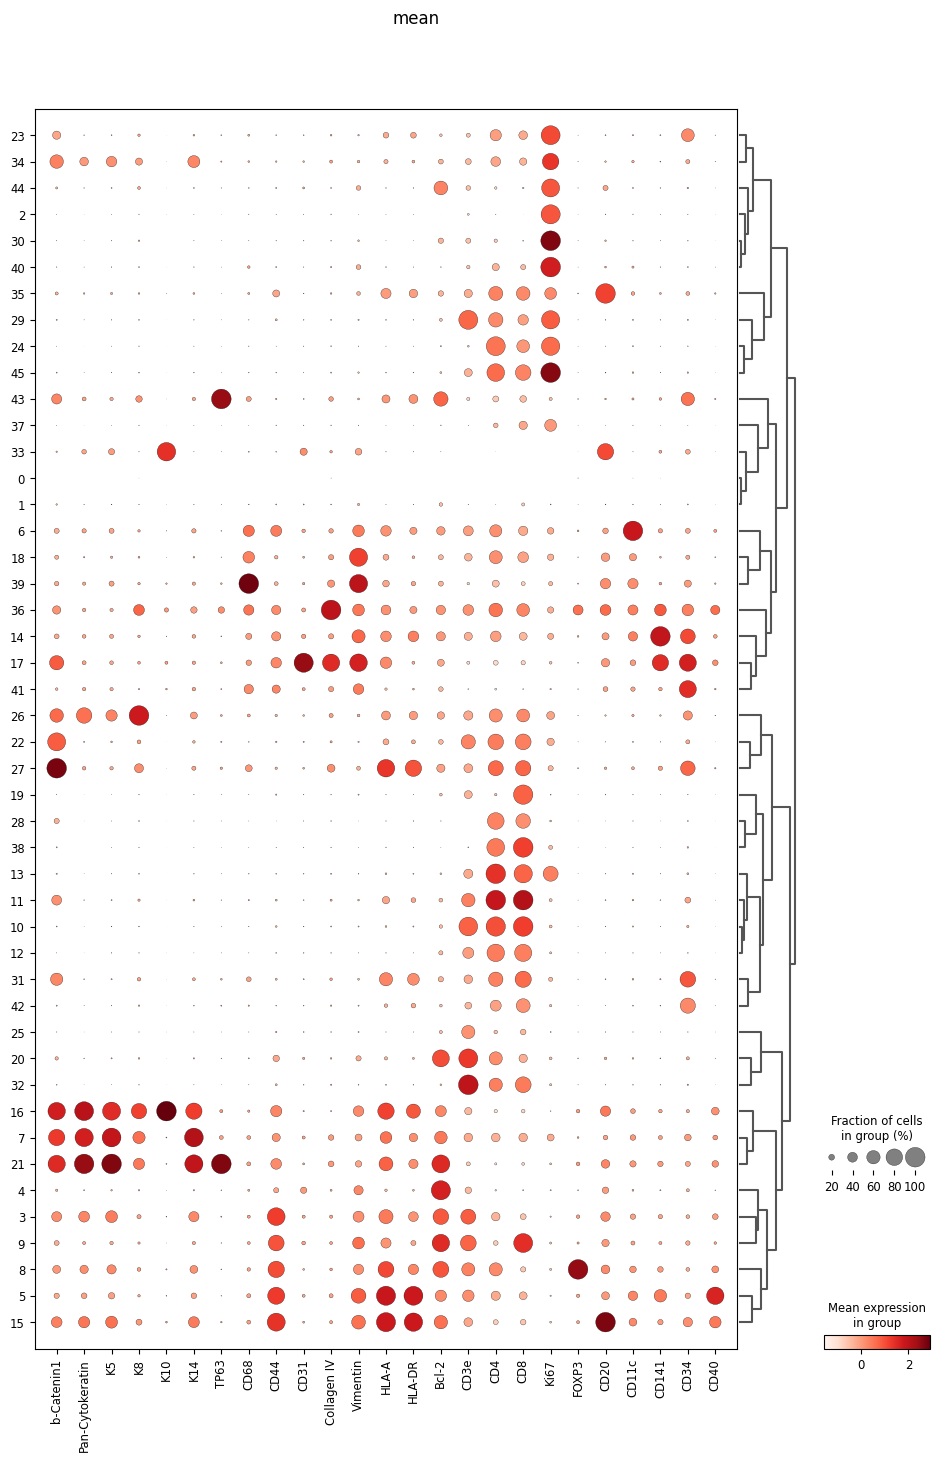

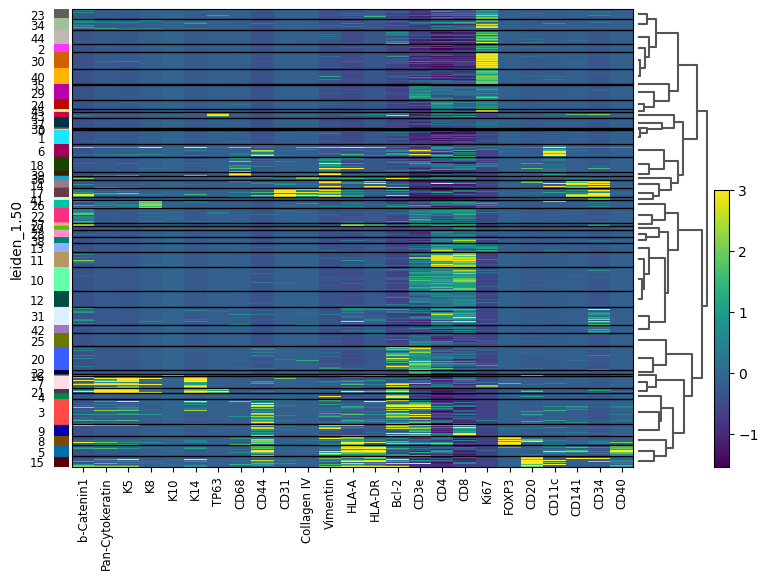

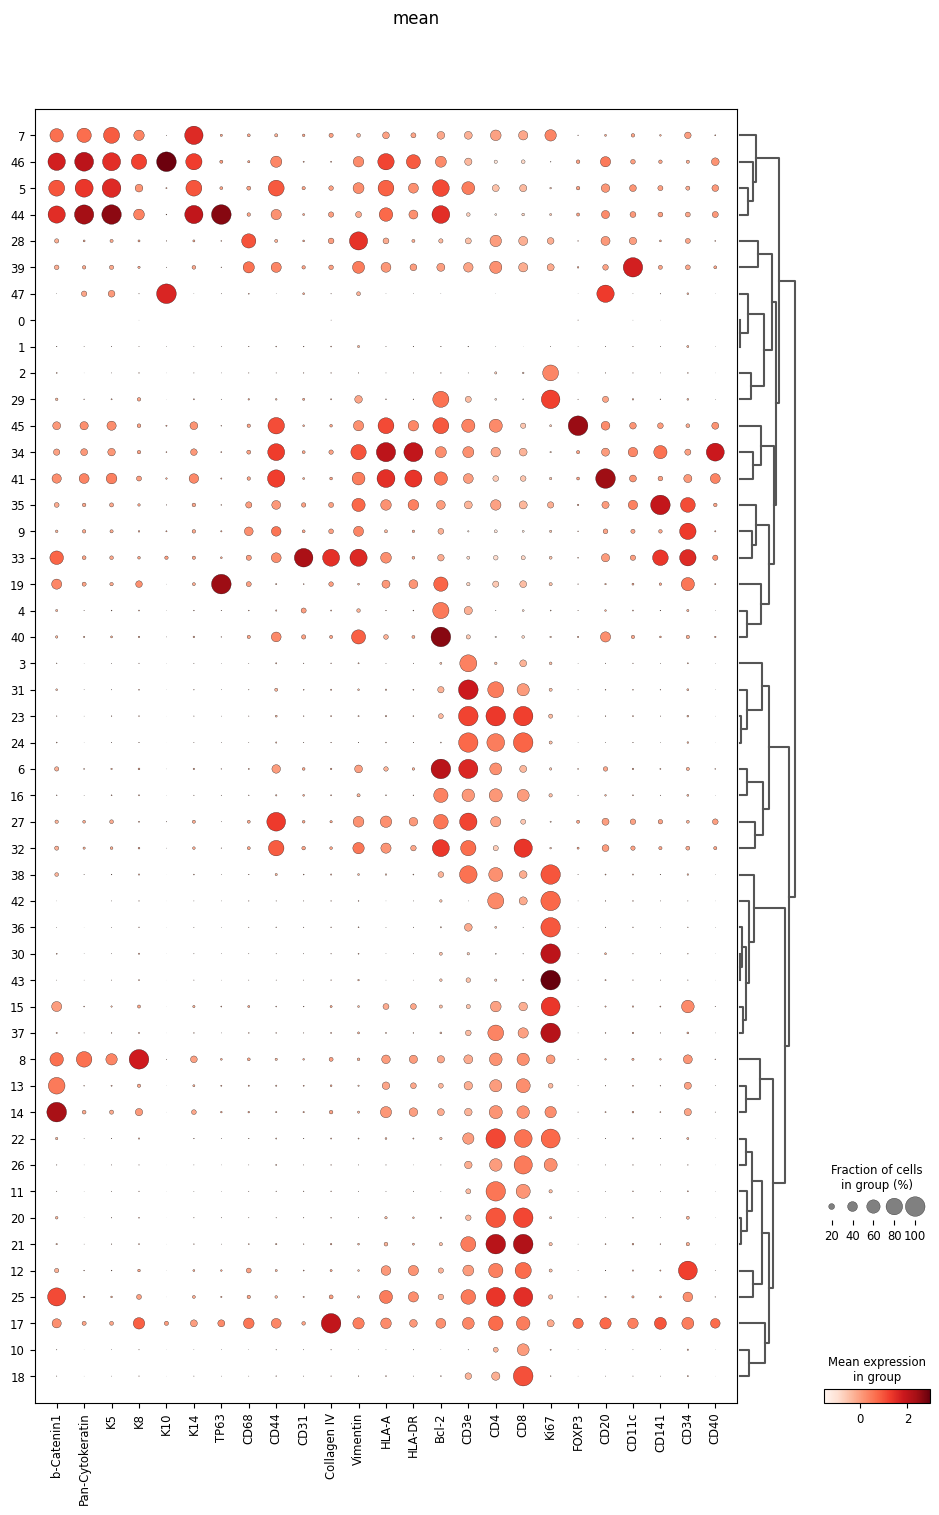

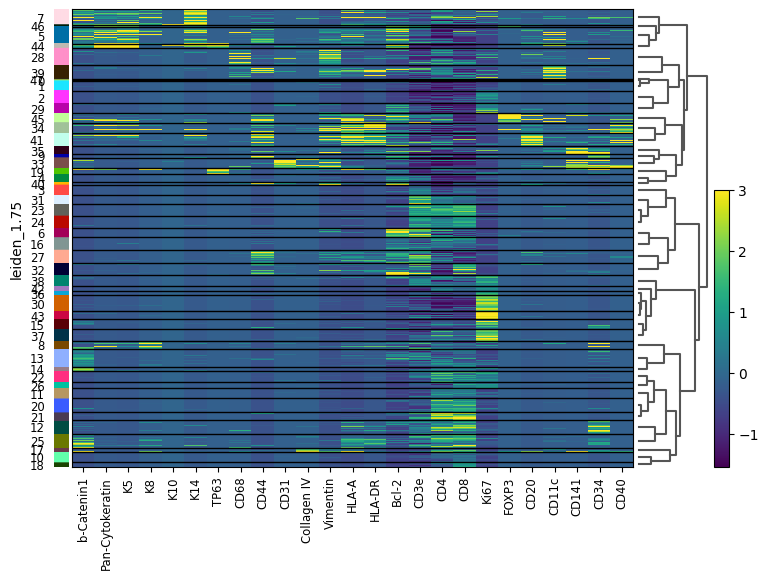

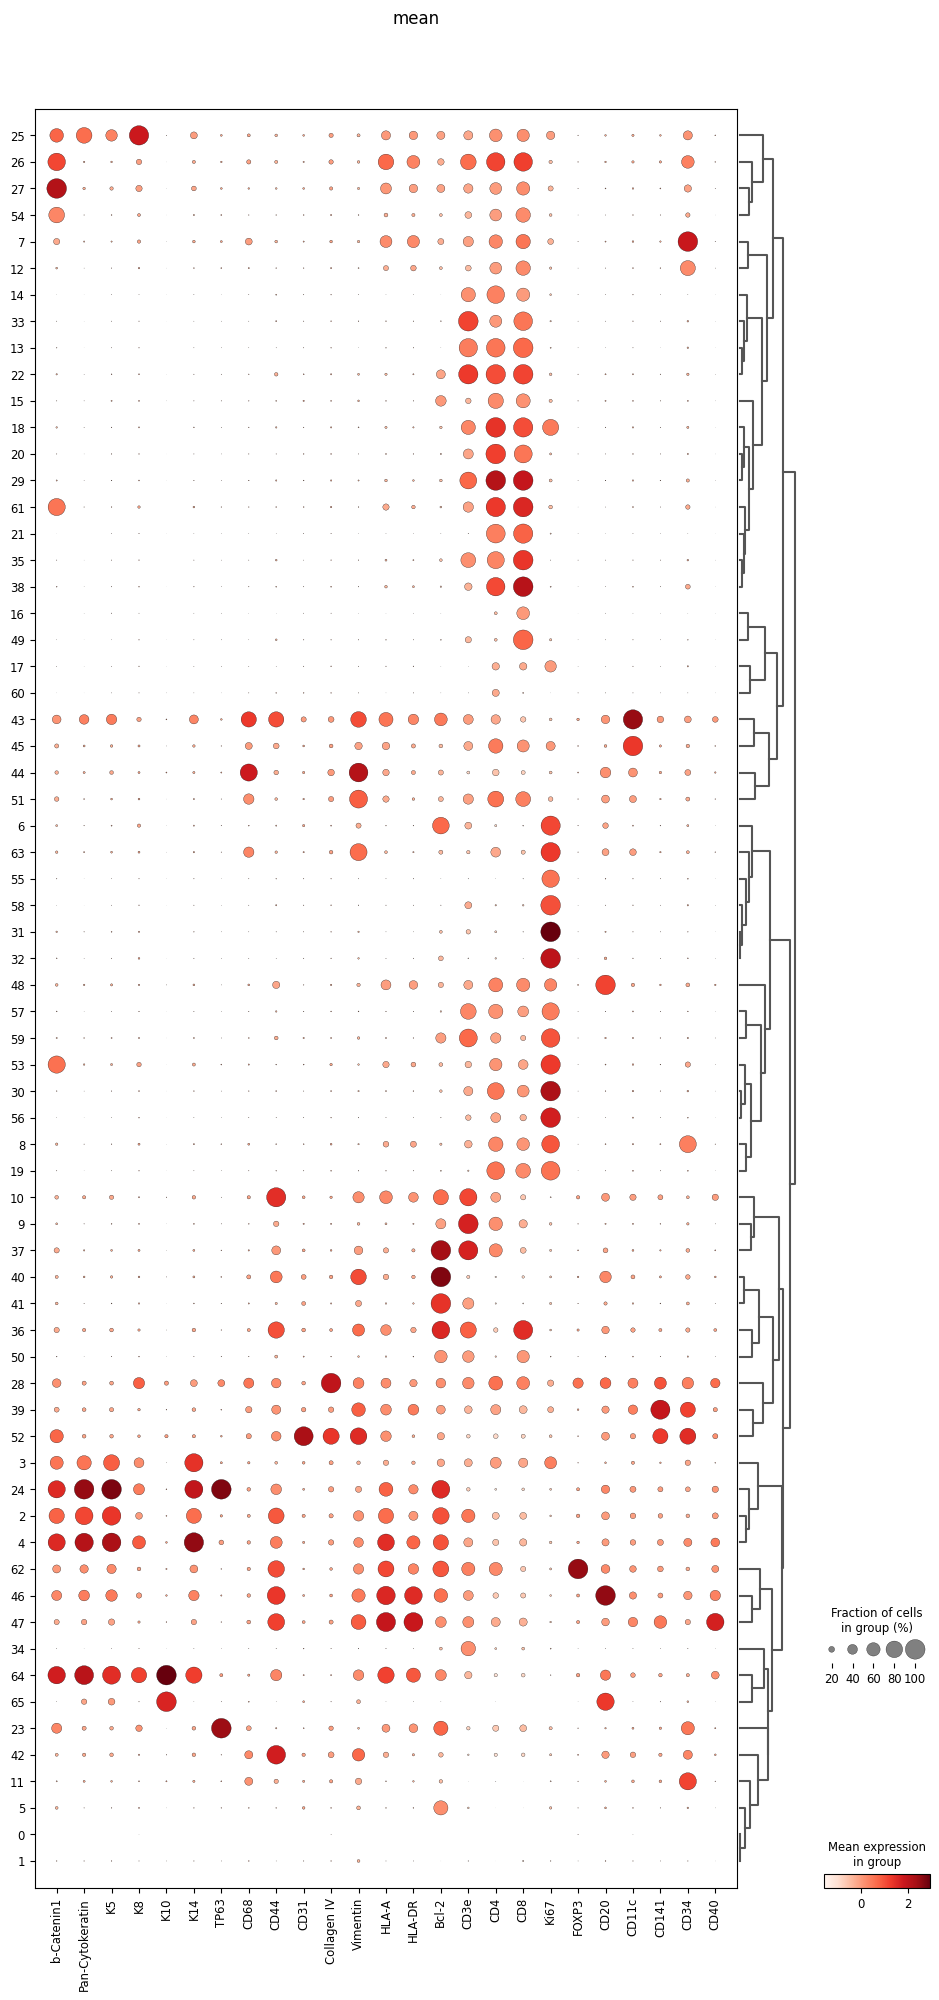

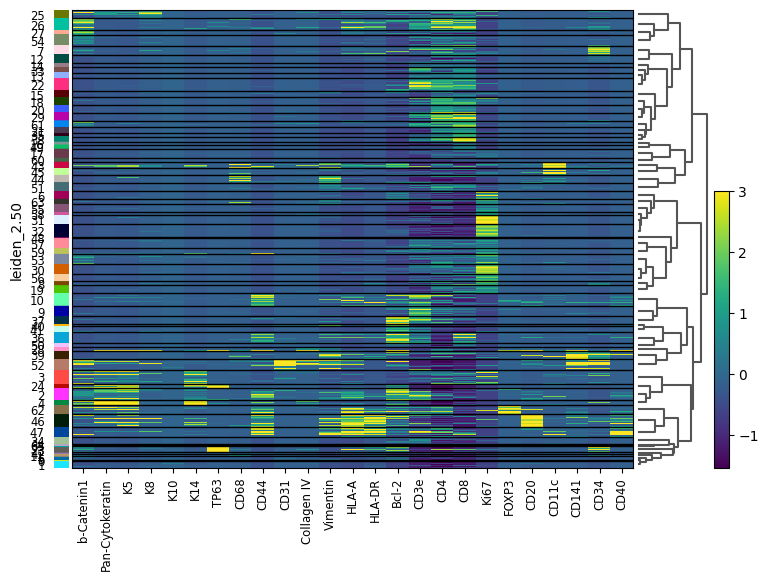

In [12]:
for res in [1.5, 1.75, 2.5]:
    sc.tl.leiden(mean_ad, key_added=f"leiden_{res:4.2f}", resolution=res, flavor="igraph")
    sc.pl.dotplot(mean_ad, groupby=f"leiden_{res:4.2f}", var_names= mean_ad.var_names, title = "mean",  dendrogram = True)
    sc.pl.heatmap(mean_ad, groupby=f"leiden_{res:4.2f}", var_names= mean_ad.var_names,  dendrogram = True)

# Full image masked with touching segmentation clustering 

In [3]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block6_patches/P49_2M/"
mean_mask_quant_df = pd.read_csv(os.path.join(img_dir, "masked_img_nonfat_cell_mask.csv"))
mean_mask_quant_df.columns = mean_mask_quant_df.columns.str.replace("_mask", "")
mean_cols = [
    'b-Catenin1', 'Pan-Cytokeratin', 'K5', 'K8', 'K10', 'K14', 'TP63', 
    'CD68', 'CD44', 'CD31', 'Collagen IV', 'Vimentin',
    'HLA-A', 'HLA-DR',
    'Bcl-2', 'CD3e', 'CD4', 'CD8','Ki67', 'FOXP3',  
    'CD20', 'CD11c', 'CD141', 'CD34', 'CD40']
mean_ad = ad.AnnData(X= mean_mask_quant_df.loc[:, mean_cols].values, obs= mean_mask_quant_df.loc[:, ["CellID", "Area", "X_centroid", "Y_centroid"]])
mean_ad.var_names = mean_cols
mean_ad = mean_ad[mean_ad.obs["Area"] > 10, :].copy()
sc.pp.scale(mean_ad)
mean_ad.X = np.clip(mean_ad.X, -3, 3) # Clip normalized values between -3 and 3                            
sc.tl.pca(mean_ad)
sc.pp.neighbors(mean_ad, use_rep= "X_pca")

/stor/work/Ehrlich/Users/John/mamba/envs/mesmer_pypi/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
2026-01-28 02:48:45.130933: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-01-28 02:48:45.130960: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


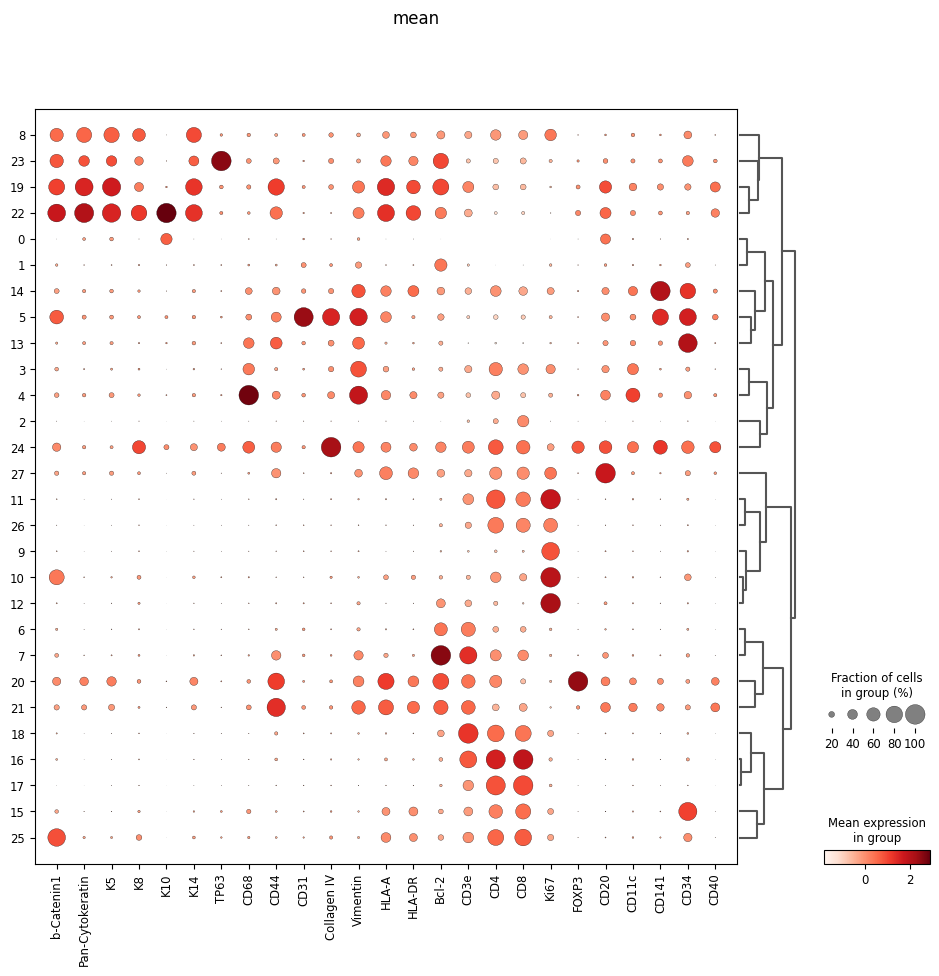

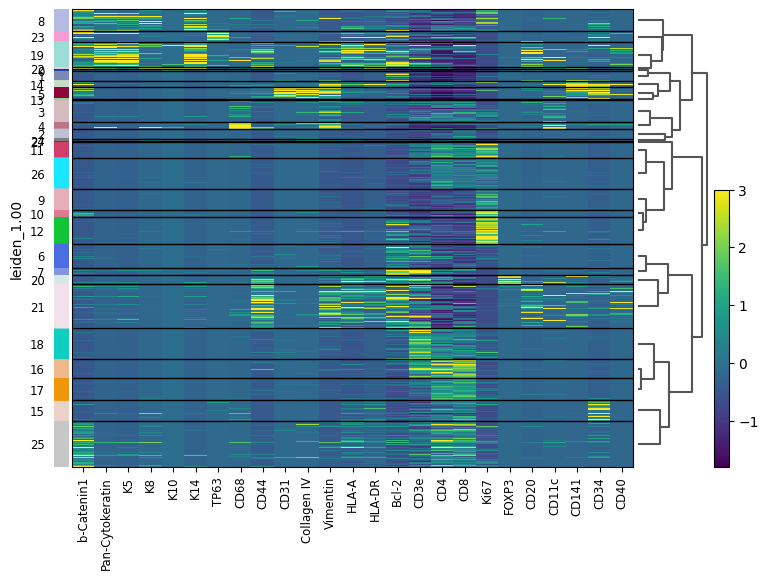

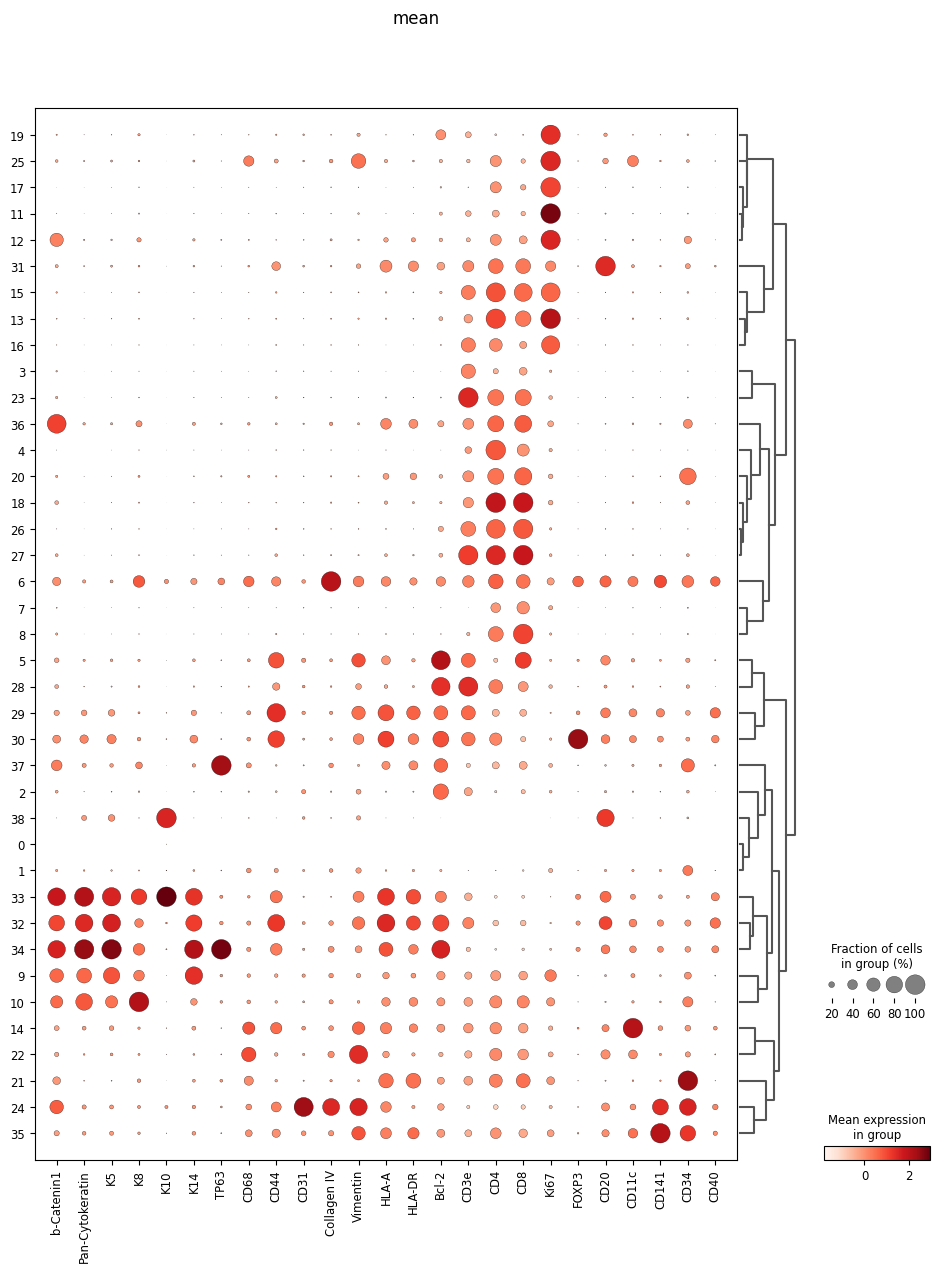

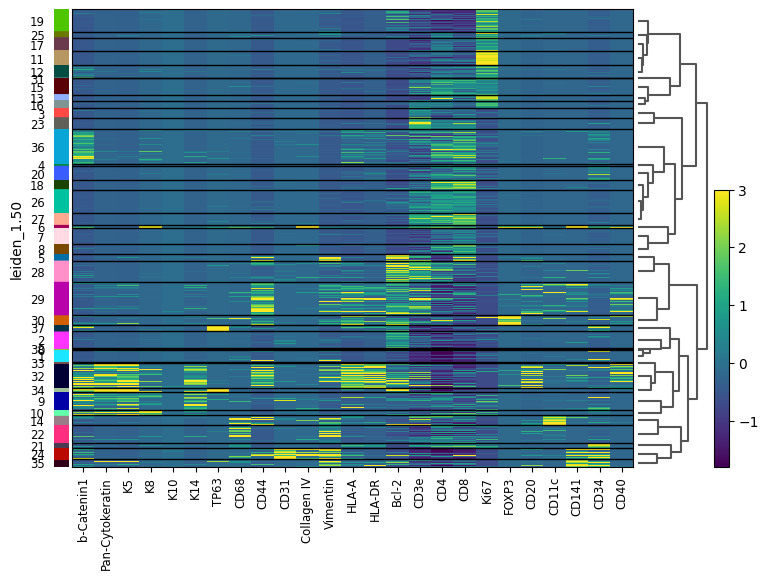

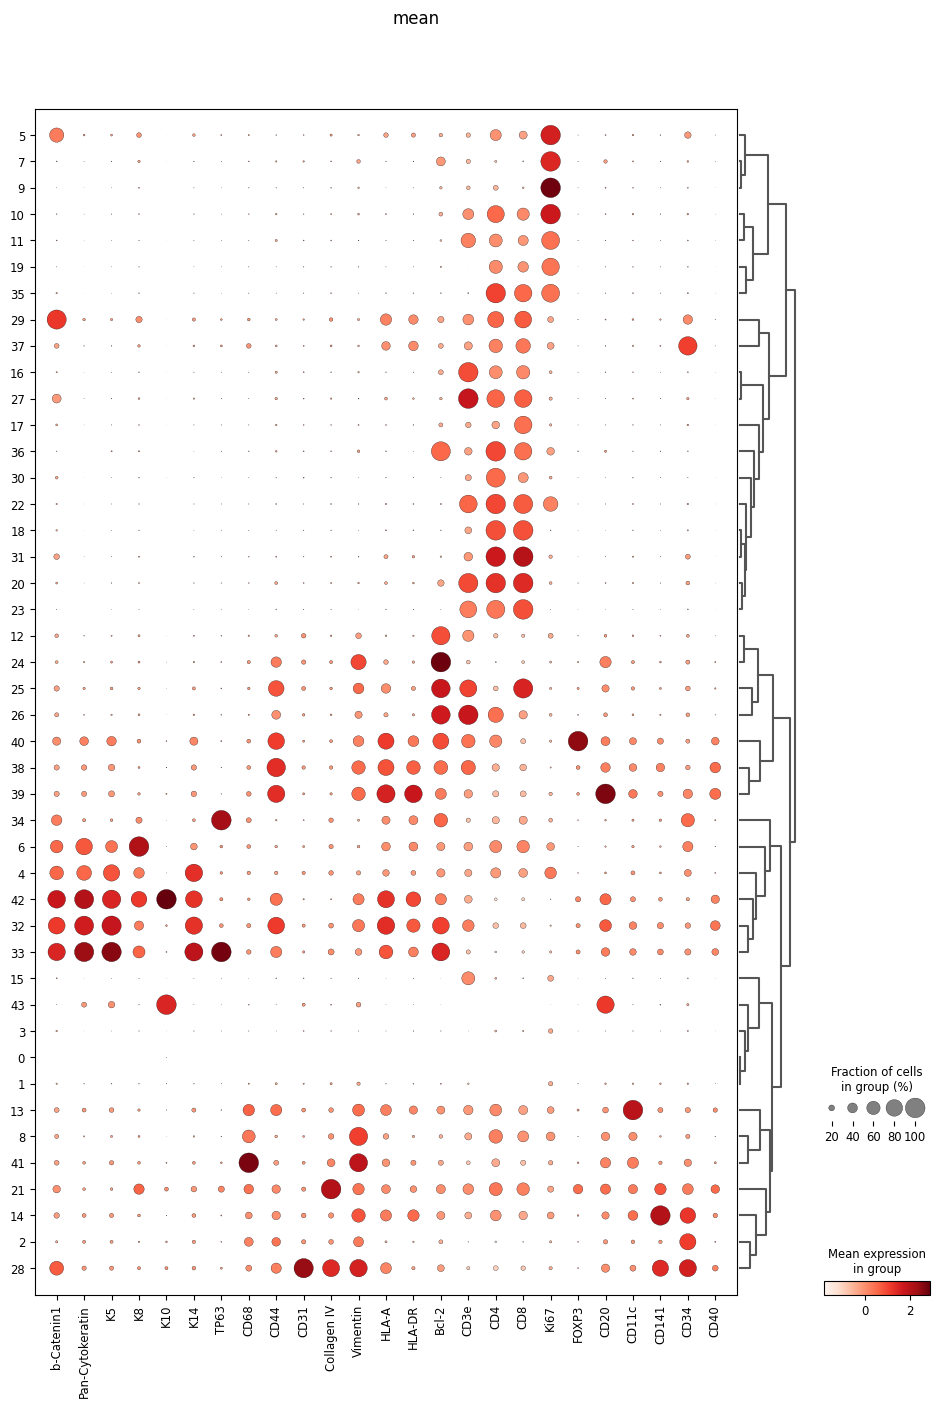

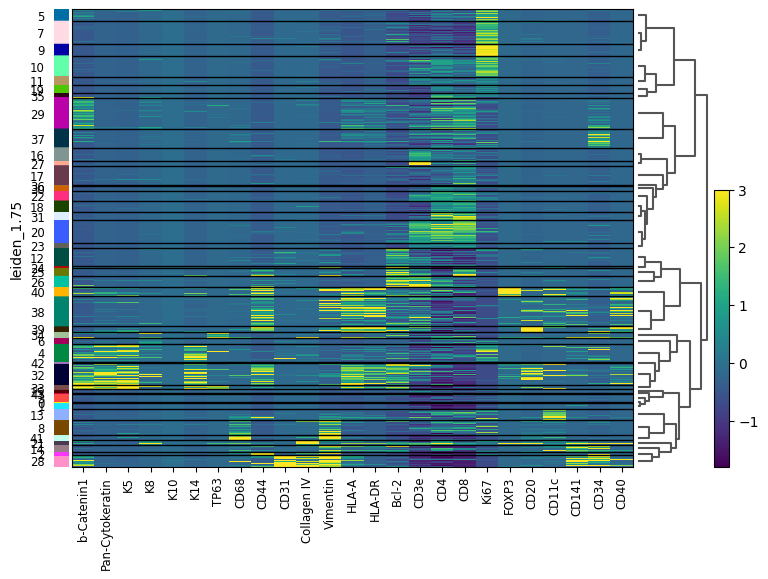

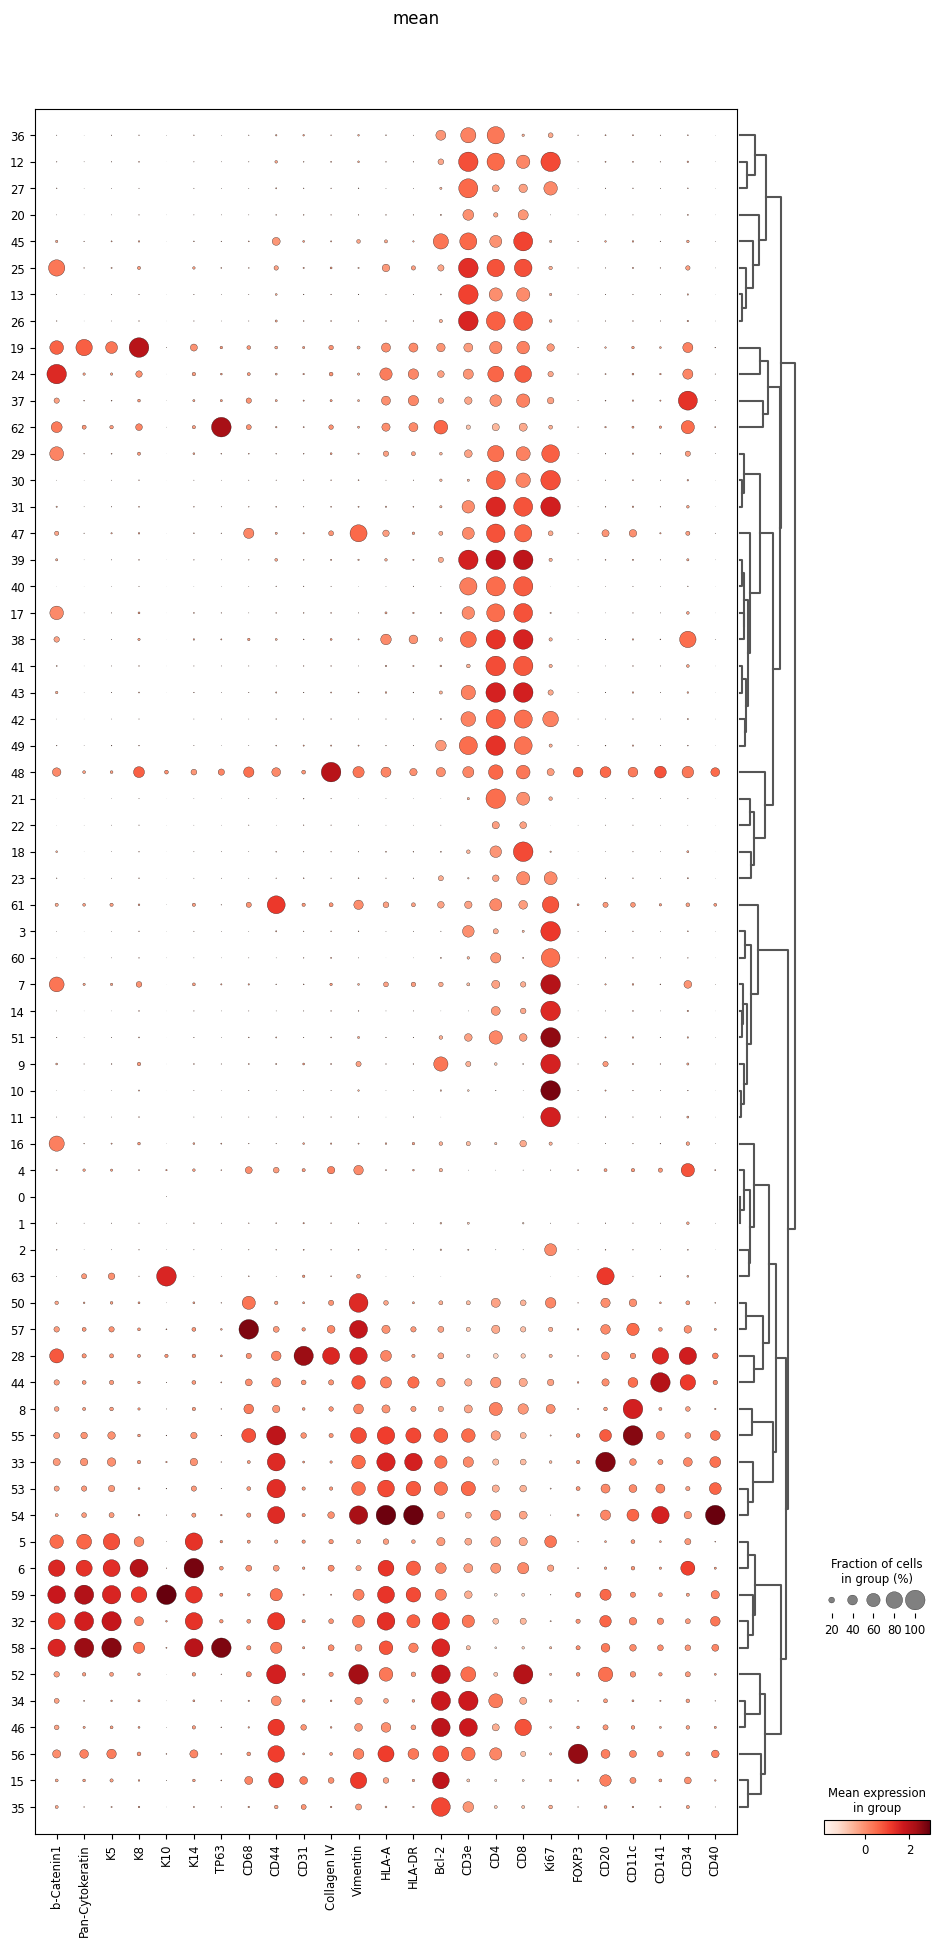

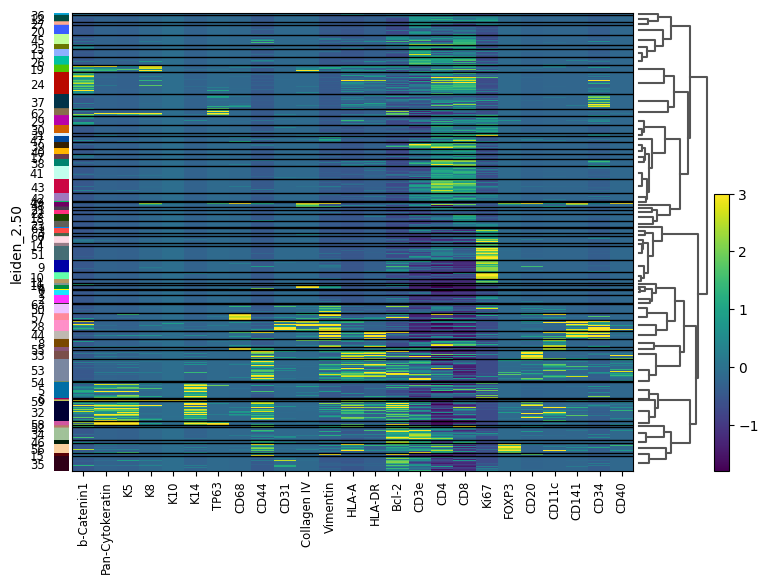

In [4]:
for res in [1, 1.5, 1.75, 2.5]:
    sc.tl.leiden(mean_ad, key_added=f"leiden_{res:4.2f}", resolution=res, flavor="igraph")
    sc.pl.dotplot(mean_ad, groupby=f"leiden_{res:4.2f}", var_names= mean_ad.var_names, title = "mean",  dendrogram = True)
    sc.pl.heatmap(mean_ad, groupby=f"leiden_{res:4.2f}", var_names= mean_ad.var_names,  dendrogram = True)

In [5]:
mean_ad.write_h5ad(os.path.join(img_dir, "filt_mask_mean_touching_leiden_clustering_full_image_2026-01-28.h5ad"))

# Full image masked with touching segmentation clustering on thymocyte markers only

In [ ]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block6_patches/P49_2M/"
mean_mask_quant_df = pd.read_csv(os.path.join(img_dir, "masked_img_nonfat_cell_mask.csv"))
mean_mask_quant_df.columns = mean_mask_quant_df.columns.str.replace("_mask", "")
mean_cols = [
    'b-Catenin1', 'Pan-Cytokeratin', 'K5', 'K8', 'K10', 'K14', 'TP63', 
    'CD68', 'CD44', 'CD31', 'Collagen IV', 'Vimentin',
    'HLA-A', 'HLA-DR',
    'Bcl-2', 'CD3e', 'CD4', 'CD8','Ki67', 'FOXP3',  
    'CD20', 'CD11c', 'CD141', 'CD34', 'CD40']
mean_ad = ad.AnnData(X= mean_mask_quant_df.loc[:, mean_cols].values, obs= mean_mask_quant_df.loc[:, ["CellID", "Area", "X_centroid", "Y_centroid"]])
mean_ad.var_names = mean_cols
mean_ad = mean_ad[mean_ad.obs["Area"] > 10, :].copy()
sc.pp.scale(mean_ad)
mean_ad.X = np.clip(mean_ad.X, -3, 3) # Clip normalized values between -3 and 3                            
sc.tl.pca(mean_ad)
sc.pp.neighbors(mean_ad, use_rep= "X_pca")

In [ ]:
for res in [1, 1.5, 1.75, 2.5]:
    sc.tl.leiden(mean_ad, key_added=f"leiden_{res:4.2f}", resolution=res, flavor="igraph")
    sc.pl.dotplot(mean_ad, groupby=f"leiden_{res:4.2f}", var_names= mean_ad.var_names, title = "mean",  dendrogram = True)
    sc.pl.heatmap(mean_ad, groupby=f"leiden_{res:4.2f}", var_names= mean_ad.var_names,  dendrogram = True)

# Full image no masking with non-touching segmentation clustering 

In [1]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block6_patches/P49_2M/"
mean_mask_quant_df = pd.read_csv(os.path.join(img_dir, "image_no_touch_nonfat_cell_mask.csv"))
mean_mask_quant_df.columns = mean_mask_quant_df.columns.str.replace("_mask", "")
mean_cols = [
    'b-Catenin1', 'Pan-Cytokeratin', 'K5', 'K8', 'K10', 'K14', 'TP63', 
    'CD68', 'CD44', 'CD31', 'Collagen IV', 'Vimentin',
    'HLA-A', 'HLA-DR',
    'Bcl-2', 'CD3e', 'CD4', 'CD8','Ki67', 'FOXP3',  
    'CD20', 'CD11c', 'CD141', 'CD34', 'CD40']
mean_ad = ad.AnnData(X= mean_mask_quant_df.loc[:, mean_cols].values, obs= mean_mask_quant_df.loc[:, ["CellID", "Area", "X_centroid", "Y_centroid"]])
mean_ad.var_names = mean_cols
mean_ad = mean_ad[mean_ad.obs["Area"] > 10, :].copy()
sc.pp.scale(mean_ad)
mean_ad.X = np.clip(mean_ad.X, -3, 3) # Clip normalized values between -3 and 3 
sc.tl.pca(mean_ad)
sc.pp.neighbors(mean_ad, use_rep= "X_pca")

NameError: name 'pd' is not defined

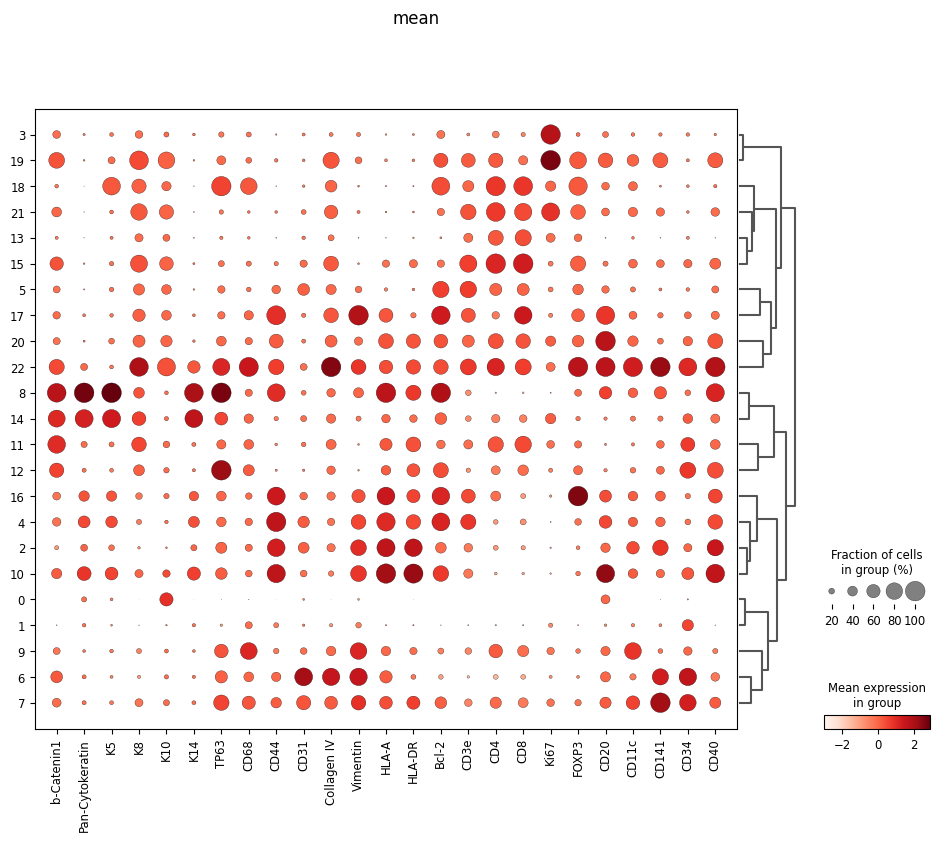

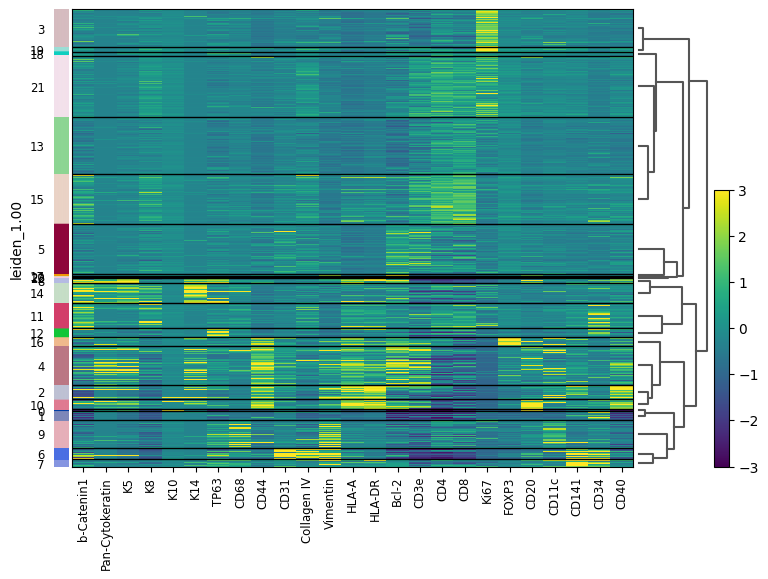

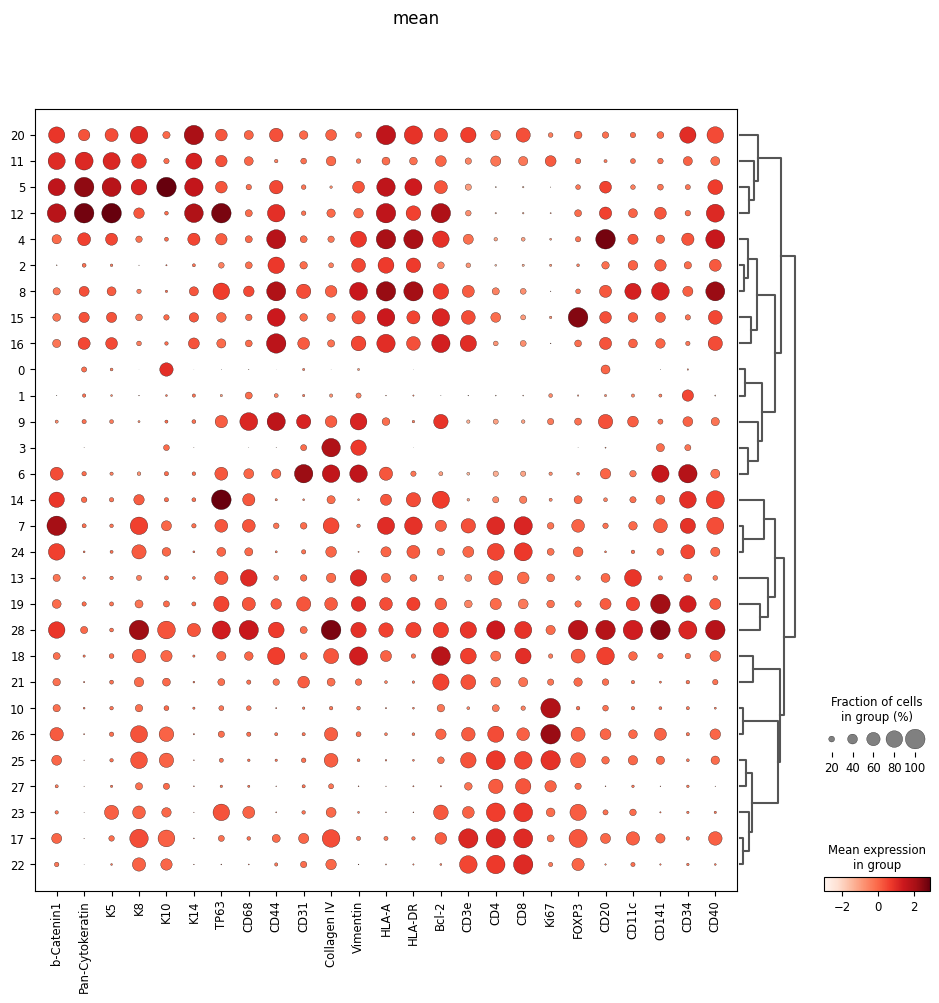

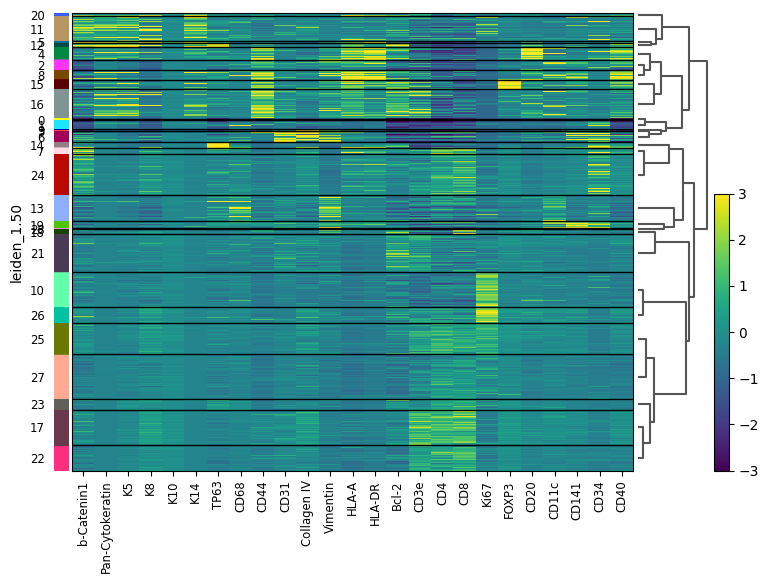

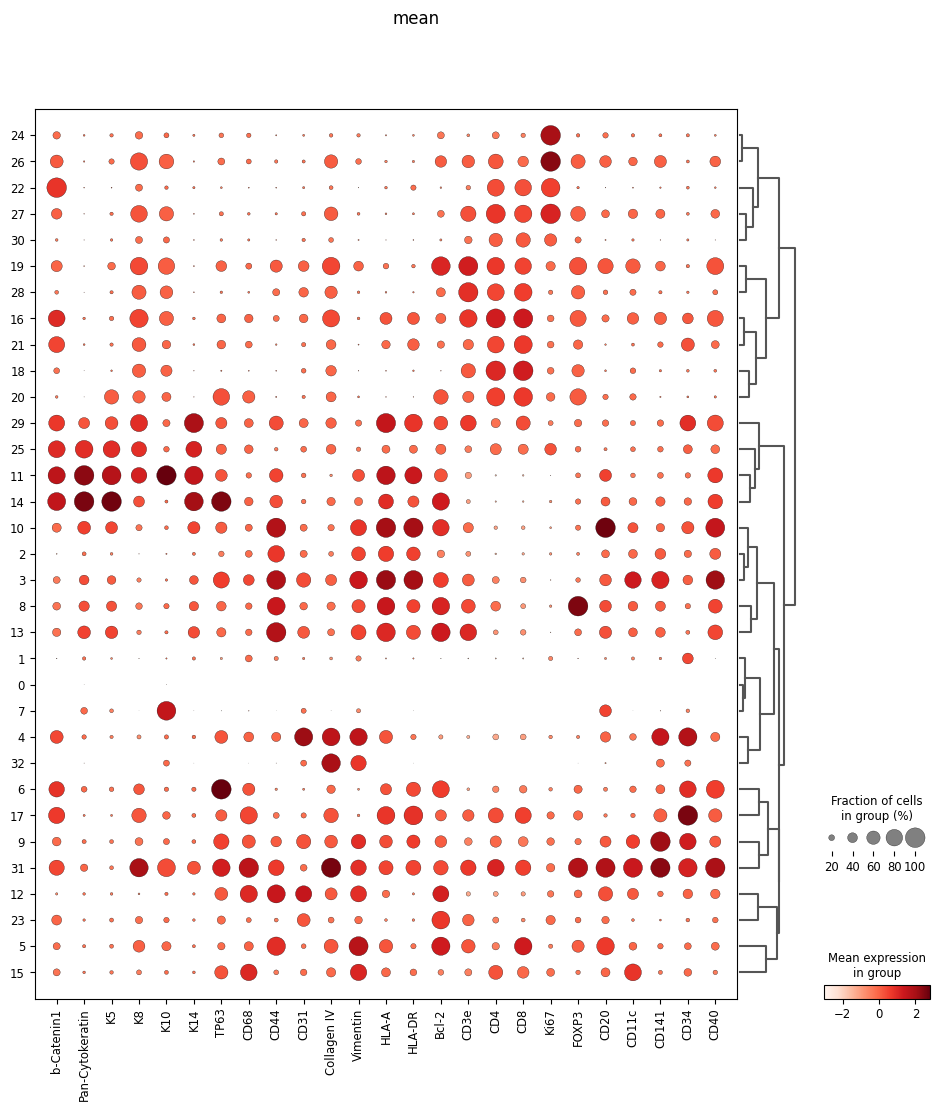

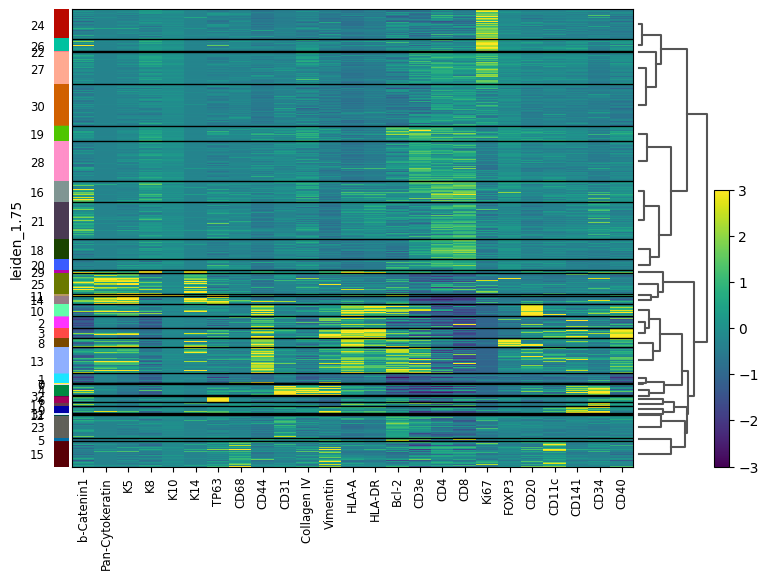

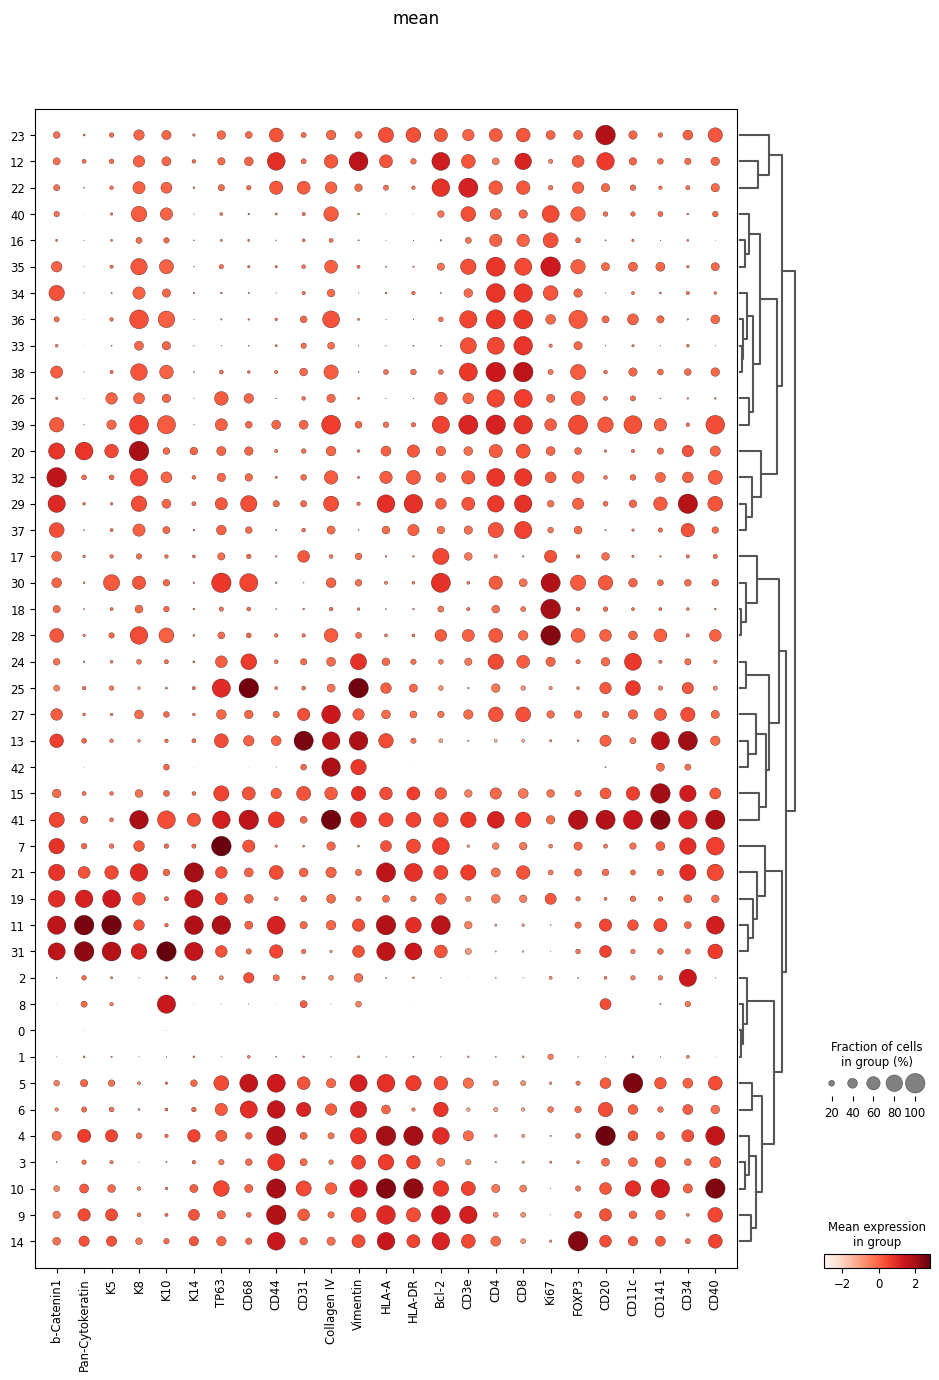

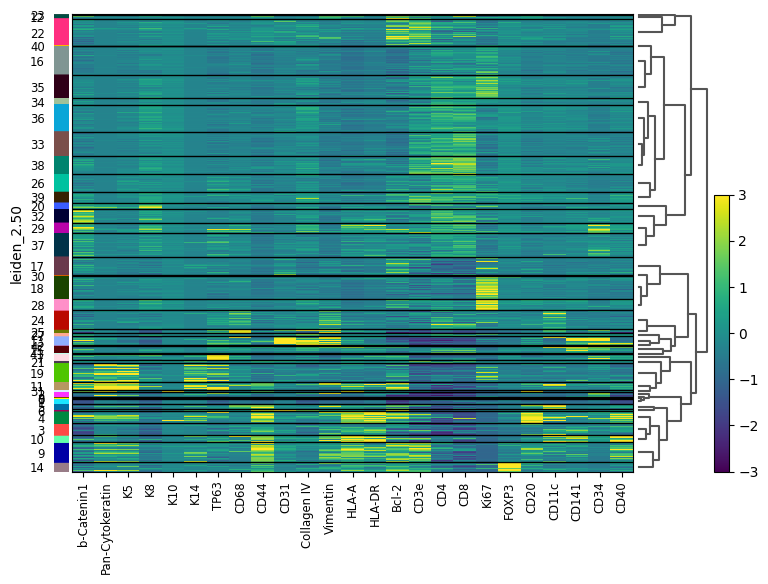

In [10]:
for res in [1, 1.5, 1.75, 2.5]:
    sc.tl.leiden(mean_ad, key_added=f"leiden_{res:4.2f}", resolution=res, flavor="igraph")
    sc.pl.dotplot(mean_ad, groupby=f"leiden_{res:4.2f}", var_names= mean_ad.var_names, title = "mean",  dendrogram = True)
    sc.pl.heatmap(mean_ad, groupby=f"leiden_{res:4.2f}", var_names= mean_ad.var_names,  dendrogram = True)